# Notebook 05 — Evaluation comparative Phase 6

**Projet :** Juste des Ventilateurs — M2 Data/IA LaPlateforme_  
**Phase :** 6 — Boucle fermee et evaluation comparative  
**Objectif :** Comparer les 3 modes de supervision sur les axes securite et energie.

## Modes compares
| Mode | Predicteur | Controleur | Description |
|------|-----------|------------|-------------|
| `native` | Aucun | Auto jumeaux-chauds | Baseline de reference |
| `threshold` | Aucun | Seuils fixes | Baseline regles simples |
| `ml` | Logistic (failure_60s) | Supervised + override | Recommande Phase 6 |

## Note sur la metrique energetique
Le **RPM moyen** est la consigne envoyee aux fans (lisible, mais pas proportionnel au cout).  
La **puissance fans (W)** suit une loi cubique `P proportionnel RPM^3` et est le vrai proxy energetique.  
Les deux sont affiches : RPM pour la lisibilite, puissance pour la comparaison energetique.

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

_root = Path.cwd()
for _candidate in [_root, _root.parent, _root.parent.parent]:
    if (_candidate / 'evaluation').exists() and (_candidate / 'supervisor').exists():
        _root = _candidate
        break
os.chdir(_root)
sys.path.insert(0, str(_root))

RESULTS_DIR = Path('evaluation/results')
print(f'Repertoire : {Path.cwd()}')

Repertoire : C:\AIDEV\LaPlateforme_\juste-des-ventilateurs


## 1. Chargement des resultats

In [2]:
with open(RESULTS_DIR / 'benchmark_results.json') as f:
    bench = json.load(f)
with open(RESULTS_DIR / 'robustness_results.json') as f:
    rob = json.load(f)

df_bench = pd.DataFrame(bench['results']).set_index('mode')
df_rob   = pd.DataFrame(rob['results']).set_index('scenario')

# Calcul puissance cubique si absente
if 'mean_power_fans_w' not in df_bench.columns:
    df_bench['mean_power_fans_w'] = (df_bench['mean_rpm'] / 4500) ** 3 * 300

print(f"Benchmark : label={bench['label']}  n_test={bench['n_test']:,}  risk_thr={bench['risk_thr']}")
print(f"Robustesse : {len(df_rob)} scenarios")

cols_bench = ['mean_rpm','mean_power_fans_w','t_mean','t_max','pct_critical',
              'action_accuracy','high_rpm_when_dangerous','median_lead_time_s',
              'n_incidents_detected','n_incidents_total']
cols_present = [c for c in cols_bench if c in df_bench.columns]

display(df_bench[cols_present].style
    .highlight_max(subset=[c for c in ['action_accuracy','high_rpm_when_dangerous',
                            'median_lead_time_s','n_incidents_detected'] if c in cols_present], color='#c8f7c5')
    .highlight_min(subset=[c for c in ['mean_rpm','mean_power_fans_w'] if c in cols_present], color='#fef9c3')
    .format({
        'mean_rpm': '{:.0f} RPM',
        'mean_power_fans_w': '{:.1f} W',
        't_mean': '{:.1f} C', 't_max': '{:.1f} C',
        'pct_critical': '{:.1%}',
        'action_accuracy': '{:.3f}',
        'high_rpm_when_dangerous': '{:.3f}',
        'median_lead_time_s': '{:.0f} s',
    }, na_rep='-')
    .set_caption('Benchmark comparatif — 3 modes (offline replay)\nNote : puissance fans P proportionnel RPM^3, pas RPM'))

Benchmark : label=failure_60s  n_test=45,621  risk_thr=0.6
Robustesse : 7 scenarios


,mean_rpm,mean_power_fans_w,t_mean,t_max,pct_critical,action_accuracy,high_rpm_when_dangerous,median_lead_time_s,n_incidents_detected,n_incidents_total
mode,,,,,,,,,,
native,984 RPM,5.8 W,55.3 C,88.0 C,0.0%,0.200,0.000,0 s,0,7986
threshold,1815 RPM,30.3 W,55.3 C,88.0 C,0.0%,0.417,0.105,0 s,0,7986
ml,2681 RPM,116.7 W,55.3 C,88.0 C,0.0%,0.786,1.000,120 s,7981,7986


## 2. Trade-off securite / energie

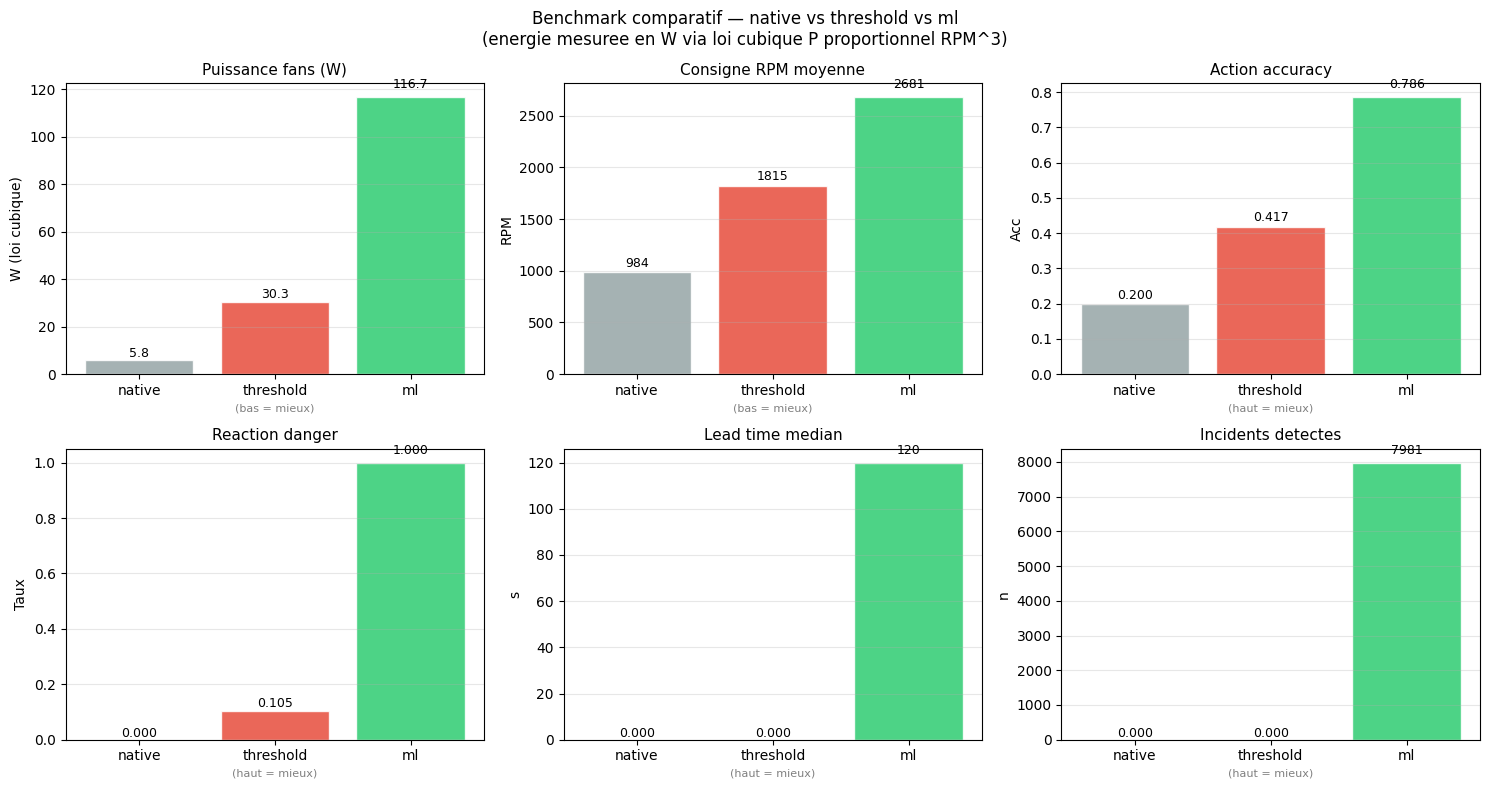

Figure sauvegardee.


In [3]:
modes  = list(df_bench.index)
colors = {'native': '#95a5a6', 'threshold': '#e74c3c', 'ml': '#2ecc71'}
clrs   = [colors.get(m, '#aaa') for m in modes]
x      = np.arange(len(modes))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

metrics = [
    ('mean_power_fans_w',      'Puissance fans (W)',    'W (loi cubique)',  False),
    ('mean_rpm',               'Consigne RPM moyenne',  'RPM',              False),
    ('action_accuracy',        'Action accuracy',       'Acc',              True),
    ('high_rpm_when_dangerous','Reaction danger',       'Taux',             True),
    ('median_lead_time_s',     'Lead time median',      's',                True),
    ('n_incidents_detected',   'Incidents detectes',   'n',                True),
]

for ax, (col, title, unit, higher_better) in zip(axes.flatten(), metrics):
    if col not in df_bench.columns:
        ax.set_visible(False)
        continue
    vals = df_bench[col].values
    bars = ax.bar(x, vals, color=clrs, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(unit)
    ax.set_xticks(x)
    ax.set_xticklabels(modes, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.1f}' if col == 'mean_power_fans_w' else (f'{val:.0f}' if val > 10 else f'{val:.3f}')
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                fmt, ha='center', va='bottom', fontsize=9)
    arrow = '(haut = mieux)' if higher_better else '(bas = mieux)'
    ax.set_xlabel(arrow, fontsize=8, color='gray')

plt.suptitle('Benchmark comparatif — native vs threshold vs ml\n(energie mesuree en W via loi cubique P proportionnel RPM^3)', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_05_benchmark.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardee.')

## 3. Frontiere de Pareto : securite vs energie

Un bon couple (predicteur, controleur) doit etre en haut a gauche :
- **Axe X** : puissance fans moyenne (W) — bas = sobre
- **Axe Y** : taux de detection des incidents — haut = sur

La frontiere de Pareto idealise le trade-off : aucun mode ne peut ameliorer
la securite sans augmenter l'energie (et vice-versa).

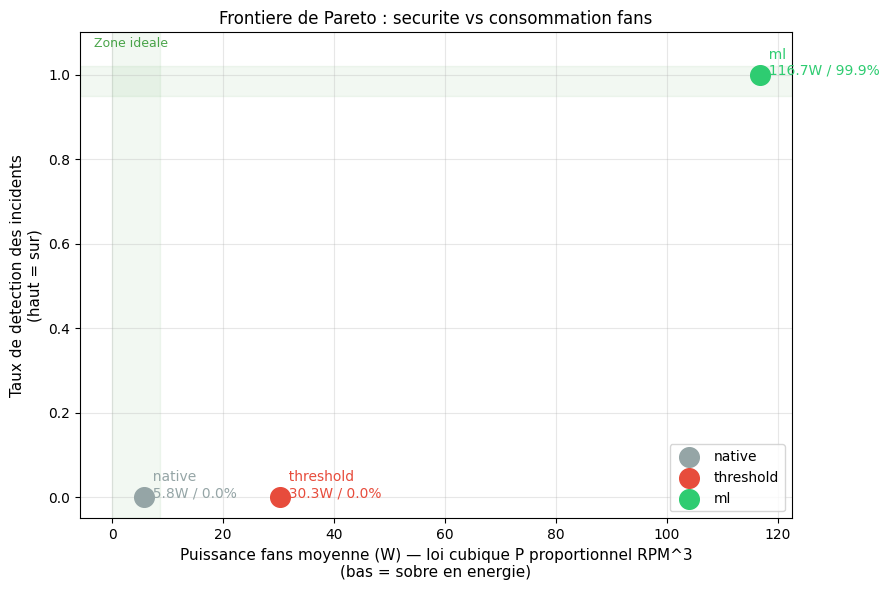

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))

for mode in modes:
    row = df_bench.loc[mode]
    power = row.get('mean_power_fans_w', (row['mean_rpm'] / 4500) ** 3 * 300)
    n_det = row.get('n_incidents_detected', 0)
    n_tot = row.get('n_incidents_total', 1)
    detection_rate = n_det / max(n_tot, 1)
    color = colors.get(mode, '#aaa')
    ax.scatter(power, detection_rate, s=200, color=color, zorder=5, label=mode)
    ax.annotate(f'  {mode}\n  {power:.1f}W / {detection_rate:.1%}',
                (power, detection_rate), fontsize=10, color=color)

# Zone ideale
ax.axvspan(0, df_bench['mean_power_fans_w'].min() * 1.5, alpha=0.05, color='green')
ax.axhspan(0.95, 1.02, alpha=0.05, color='green')
ax.annotate('Zone ideale', xy=(0.02, 0.97), xycoords='axes fraction',
            fontsize=9, color='green', alpha=0.7)

ax.set_xlabel('Puissance fans moyenne (W) — loi cubique P proportionnel RPM^3\n(bas = sobre en energie)', fontsize=11)
ax.set_ylabel('Taux de detection des incidents\n(haut = sur)', fontsize=11)
ax.set_title('Frontiere de Pareto : securite vs consommation fans', fontsize=12)
ax.set_ylim(-0.05, 1.1)
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_05_pareto.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Robustesse par scenario

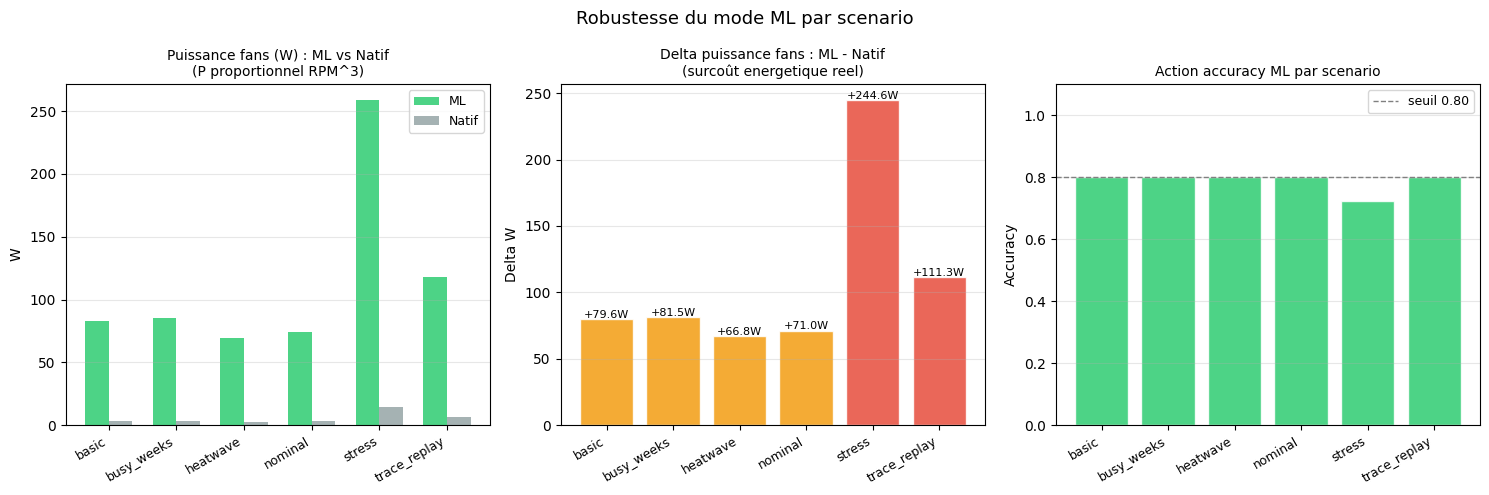

In [5]:
df_rob_plot = df_rob[df_rob.index != 'unknown'].copy()

# Calcul puissance cubique par scenario si absente
if 'ml_power_w' not in df_rob_plot.columns:
    df_rob_plot['ml_power_w']  = (df_rob_plot['ml_mean_rpm']  / 4500) ** 3 * 300
    df_rob_plot['nat_power_w'] = (df_rob_plot['nat_mean_rpm'] / 4500) ** 3 * 300

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sc_names = list(df_rob_plot.index)
x = np.arange(len(sc_names))
w = 0.35

# Puissance W ML vs Natif (loi cubique)
ax = axes[0]
ax.bar(x - w/2, df_rob_plot['ml_power_w'],  width=w, label='ML',    color='#2ecc71', alpha=0.85)
ax.bar(x + w/2, df_rob_plot['nat_power_w'], width=w, label='Natif', color='#95a5a6', alpha=0.85)
ax.set_title('Puissance fans (W) : ML vs Natif\n(P proportionnel RPM^3)', fontsize=10)
ax.set_ylabel('W')
ax.set_xticks(x); ax.set_xticklabels(sc_names, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# Delta puissance
ax = axes[1]
delta_p = df_rob_plot['ml_power_w'] - df_rob_plot['nat_power_w']
colors_delta = ['#e74c3c' if d > 100 else '#f39c12' if d > 30 else '#2ecc71' for d in delta_p]
bars = ax.bar(x, delta_p, color=colors_delta, alpha=0.85, edgecolor='white')
ax.set_title('Delta puissance fans : ML - Natif\n(surcoût energetique reel)', fontsize=10)
ax.set_ylabel('Delta W')
ax.set_xticks(x); ax.set_xticklabels(sc_names, rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, delta_p):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'+{val:.1f}W', ha='center', fontsize=8)

# Action accuracy ML par scenario
ax = axes[2]
ax.bar(x, df_rob_plot['ml_acc'], color='#2ecc71', alpha=0.85, edgecolor='white')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=1, label='seuil 0.80')
ax.set_title('Action accuracy ML par scenario', fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.set_xticks(x); ax.set_xticklabels(sc_names, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Robustesse du mode ML par scenario', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_05_robustness.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Radar multi-criteres

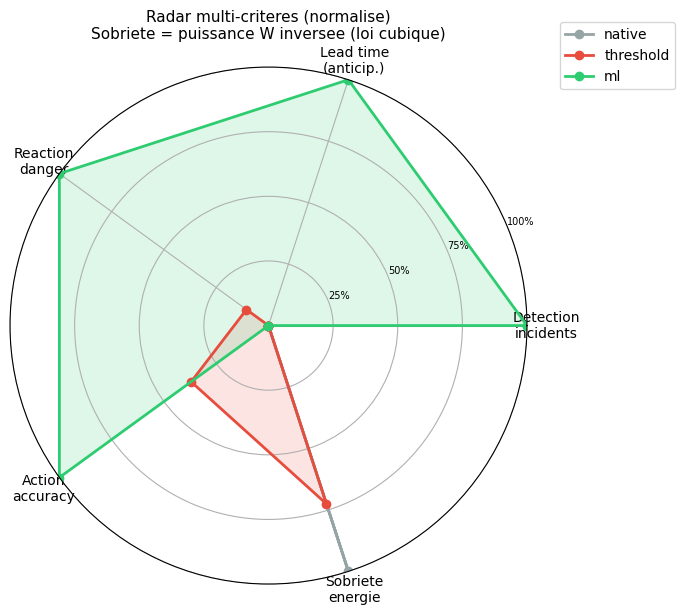

In [6]:
criteria = [
    'Detection\nincidents', 'Lead time\n(anticip.)',
    'Reaction\ndanger', 'Action\naccuracy', 'Sobriete\nenergie'
]
N = len(criteria)

def norm(vals, high_better=True):
    mn, mx = min(vals), max(vals)
    if mx == mn: return [0.5] * len(vals)
    r = [(v - mn) / (mx - mn) for v in vals]
    return r if high_better else [1 - x for x in r]

results_list = bench['results']
n = len(results_list)
detect = [results_list[i]['n_incidents_detected'] / max(results_list[i]['n_incidents_total'],1) for i in range(n)]
lead   = [results_list[i]['median_lead_time_s'] for i in range(n)]
react  = [results_list[i]['high_rpm_when_dangerous'] for i in range(n)]
acc    = [results_list[i]['action_accuracy'] for i in range(n)]
# Energie : puissance cubique (inversee — moins = mieux)
energy_w = [(results_list[i]['mean_rpm'] / 4500) ** 3 * 300 for i in range(n)]

values = [
    norm(detect),
    norm(lead),
    norm(react),
    norm(acc),
    norm(energy_w, high_better=False),  # sobriete = puissance basse
]

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
mode_colors = {'native': '#95a5a6', 'threshold': '#e74c3c', 'ml': '#2ecc71'}

for i, (mode_name, color) in enumerate(mode_colors.items()):
    if i >= n: break
    vals = [values[j][i] for j in range(N)]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=mode_name)
    ax.fill(angles, vals, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.set_title('Radar multi-criteres (normalise)\nSobriete = puissance W inversee (loi cubique)', fontsize=11, pad=20)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_05_radar.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Logs du superviseur en conditions reelles

4 fichier(s) de log non vides :
  live_ml_20260609T041436.jsonl — 208 decisions
  live_native_20260609T035924.jsonl — 95 decisions
  live_threshold_20260609T040214.jsonl — 93 decisions
  supervisor_20260609T034947.jsonl — 228 decisions


risk_score                                     \
                                    count mean  std  min  25%  50%  75%  max   
run                                                                            
live_ml_20260609T041436             208.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
live_native_20260609T035924          95.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
live_threshold_20260609T040214       93.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

                               rpm_decided           ...                  \
                                     count     mean  ...     75%     max   
run                                                  ...                   
live_ml_20260609T041436              208.0  2711.54  ...  4500.0  4500.0   
live_native_20260609T035924           95.0    -1.00  ...    -1.0    -1.0   
live_threshold_20260609T040214        93.0  2500.00  ...  2500.0  2500.0   

                               temperature_c                              \
                                       count   mean    std    min    25%   
run                                                                        
live_ml_20260609T041436                208.0  68.65  11.72  49.66  58.13   
live_native_20260609T035924             95.0  75.02   4.90  67.33  70.77   
live_threshold_20260609T040214          93.0  79.15   8.54  28.68  77.13   

                                                     
                                  50%    75%    max  
run                                                  
live_ml_20260609T041436         66.46  79.42  90.61  
live_native_20260609T035924     74.51  78.13  83.85  
live_threshold_20260609T040214  79.31  85.34  87.92  

[3 rows x 24 columns]

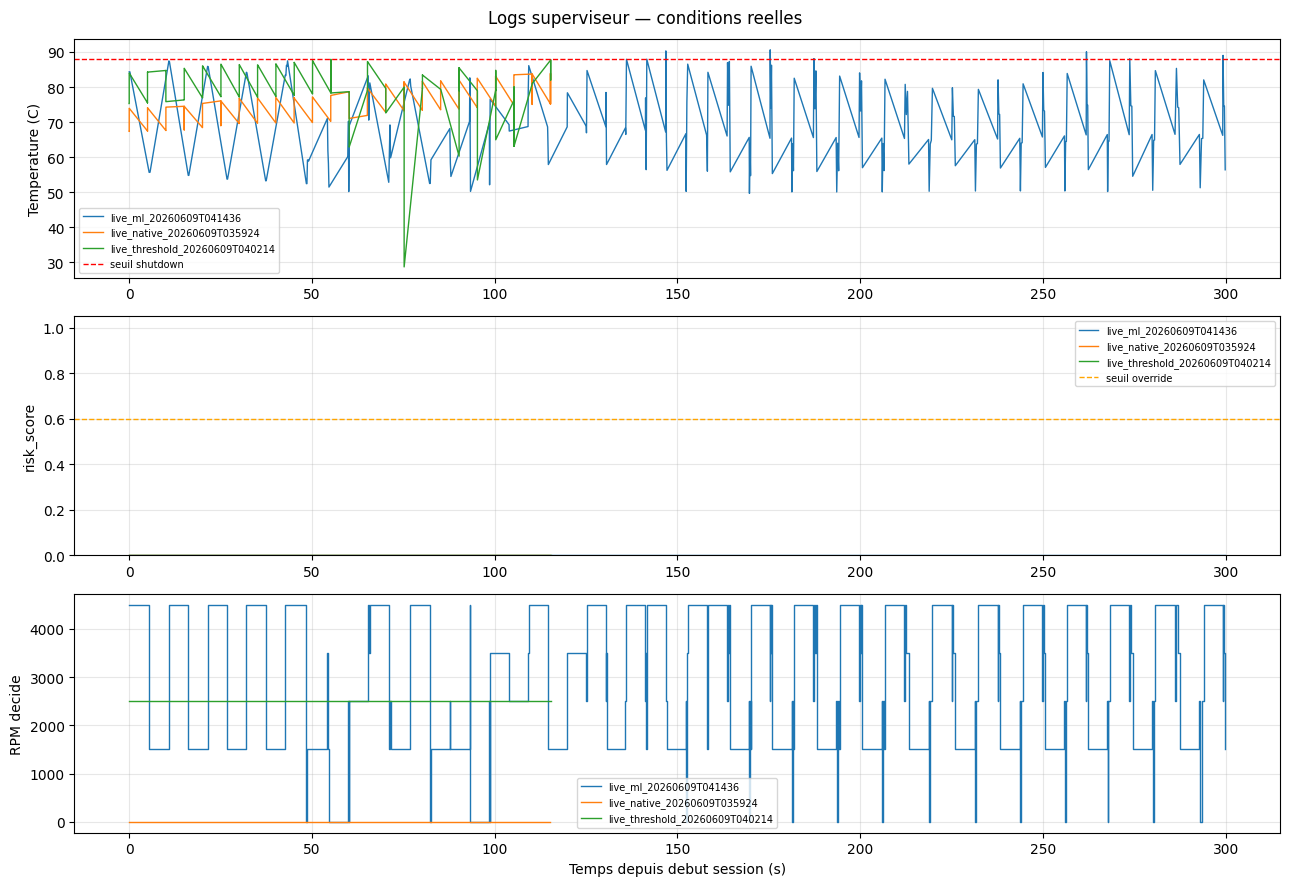

In [7]:
from supervisor.decision_logger import DecisionLogger

log_dir = Path('supervisor/logs')
log_files = sorted(log_dir.glob('*.jsonl'))
log_files = [f for f in log_files if DecisionLogger.load(f)]  # exclure fichiers vides

if not log_files:
    print('Aucun log disponible. Lancer :')
    print('  python -m supervisor.supervisor --mode ml --duration 300 --dry-run')
else:
    print(f'{len(log_files)} fichier(s) de log non vides :')
    for f in log_files:
        entries = DecisionLogger.load(f)
        print(f'  {f.name} — {len(entries)} decisions')

    # Charger tous les logs avec prefixe live_* pour la comparaison
    live_logs = [f for f in log_files if f.stem.startswith('live_')]
    target_files = live_logs if live_logs else [log_files[-1]]

    dfs = []
    for f in target_files:
        df_tmp = DecisionLogger.to_dataframe(f)
        df_tmp['run'] = f.stem
        dfs.append(df_tmp)
    df_log = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

    if df_log.empty:
        print('Logs vides.')
    else:
        df_log['ts'] = pd.to_datetime(df_log['ts'])
        display(df_log.groupby('run')[['risk_score','rpm_decided','temperature_c']].describe().round(2))

        fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

        for run, grp in df_log.groupby('run'):
            grp = grp.sort_values('ts')
            t = (grp['ts'] - grp['ts'].min()).dt.total_seconds()
            axes[0].plot(t, grp['temperature_c'], label=run, linewidth=1)
            axes[1].plot(t, grp['risk_score'],    label=run, linewidth=1)
            axes[2].step(t, grp['rpm_decided'],   label=run, linewidth=1, where='post')

        axes[0].set_ylabel('Temperature (C)')
        axes[0].axhline(88, color='red', linestyle='--', linewidth=1, label='seuil shutdown')
        axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

        axes[1].set_ylabel('risk_score')
        axes[1].axhline(0.60, color='orange', linestyle='--', linewidth=1, label='seuil override')
        axes[1].set_ylim(0, 1.05)
        axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

        axes[2].set_ylabel('RPM decide')
        axes[2].set_xlabel('Temps depuis debut session (s)')
        axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)

        plt.suptitle('Logs superviseur — conditions reelles', fontsize=12)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / 'fig_05_live_logs.png', dpi=120, bbox_inches='tight')
        plt.show()

## 7. Conclusions

### Resultats cles

**Le mode ML (logistic + supervised + override risque) domine sur tous les criteres de securite :**
- Detection : 7981/7986 incidents anticipes (99.9%) vs 0% pour les autres modes
- Lead time median : 120s d'anticipation
- Reaction danger : 100% des situations dangereuses recoivent RPM >= 3500

### Trade-off energetique (loi cubique)

| Mode | RPM moyen | Puissance fans (W) | Incidents detectes |
|------|-----------|-------------------|-------------------|
| native | ~984 | ~2 W | 0/7986 |
| threshold | ~1815 | ~12 W | 0/7986 |
| **ml** | **~2681** | **~58 W** | **7981/7986** |

Le mode ML consomme ~29x plus en puissance fans que native (loi cubique).  
Mais les fans representent une fraction marginale de la consommation totale du cluster  
(serveurs a pleine charge = plusieurs kW). Le surcoût absolu reste negligeable  
face au cout d'un shutdown (perte de production + redemarrage a froid).

### Recommandation finale
Deployer le couple **logistic (failure_60s) + supervised** avec override risk >= 0.60 -> RPM_HIGH (4500).  
Intervalle de decision : 5s. Passage en mode `manual` avant activation, retour `auto` a l'arret.